# IBM SkillsBuild Data Analytics Internship Project
## Student Performance, Attendance & Academic Analytics
**Author:** Revanth  
**Program:** AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 (BharatCares)  
**Domain:** Educational Data Analytics & Business Intelligence

---
### 📌 Project Overview
Educational institutions collect vast amounts of student-level data, including attendance records, study habits, assignment completion, and academic performance scores. However, raw data alone does not provide actionable insights for academic monitoring.

This project delivers an end-to-end **Data Analytics** workflow:
1. Data ingestion, quality audit, and duplicate removal.
2. Descriptive statistical analysis of student metrics.
3. Categorical breakdown and rule-based risk classification for academically vulnerable students.
4. Exploratory Data Analysis (EDA) and multi-variable correlation insights.
5. Key analytical findings and institutional recommendations.



In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual Theme Setup
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.titlesize"] = 14

print("Data Analytics libraries loaded successfully.")


Data Analytics libraries loaded successfully.


### 1. Data Ingestion & Quality Audit
We load `student_performance.csv` and inspect its dimensions, data types, missing values, and duplicate rows.


In [2]:
df = pd.read_csv("student_performance.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info()


Dataset Shape: 14003 rows, 16 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade    

In [3]:
# Display first 5 rows
df.head()


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [4]:
# Data Integrity & Duplicate Check
missing_count = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()

print(f"Missing Values: {missing_count}")
print(f"Duplicate Rows Found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. Cleaned Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Missing Values: 0
Duplicate Rows Found: 1534
Duplicates removed. Cleaned Dataset Shape: 12469 rows, 16 columns


### 2. Descriptive Statistics & Metric Summaries
We generate summary statistics to understand score distributions, central tendencies, and spreads across key academic metrics.


In [5]:
# Descriptive statistics for continuous metrics
df[["StudyHours", "Attendance", "AssignmentCompletion", "ExamScore", "OnlineCourses"]].describe().T


,count,mean,std,min,25%,50%,75%,max
StudyHours,12469.0,20.034405,6.049485,5.0,16.0,20.0,24.0,44.0
Attendance,12469.0,80.239233,11.469028,60.0,70.0,80.0,90.0,100.0
AssignmentCompletion,12469.0,74.515358,14.657687,50.0,62.0,74.0,87.0,100.0
ExamScore,12469.0,70.310691,17.696639,40.0,55.0,70.0,86.0,100.0
OnlineCourses,12469.0,9.872404,6.114025,0.0,5.0,10.0,15.0,20.0


In [6]:
# Key Metrics Overview
avg_score = df["ExamScore"].mean()
avg_attendance = df["Attendance"].mean()
avg_study = df["StudyHours"].mean()

print(f"Average Exam Score: {avg_score:.2f}")
print(f"Average Attendance Rate: {avg_attendance:.2f}%")
print(f"Average Study Hours/Week: {avg_study:.2f} hours")


Average Exam Score: 70.31
Average Attendance Rate: 80.24%
Average Study Hours/Week: 20.03 hours


### 3. Data Transformation & Rule-Based Risk Analytics
To facilitate academic monitoring, we segment students into analytical categories:
- **Performance Category**:
  - `Excellent`: Exam Score ≥ 80
  - `Good`: 60 ≤ Exam Score < 80
  - `Average`: Exam Score < 60
- **At-Risk Student Flag**:
  - Defined rule: `Attendance < 75%` OR `Exam Score < 40`


In [7]:
def categorize_performance(score):
    if score >= 80:
        return "Excellent"
    elif score >= 60:
        return "Good"
    else:
        return "Average"

df["Performance_Category"] = df["ExamScore"].apply(categorize_performance)

# Rule-based At-Risk Indicator (Yes/No)
df["At_Risk"] = np.where((df["Attendance"] < 75) | (df["ExamScore"] < 40), "Yes", "No")

print("--- Performance Category Breakdown ---")
print(df["Performance_Category"].value_counts())
print("\n--- At-Risk Student Classification ---")
print(df["At_Risk"].value_counts())
print("\n--- At-Risk Percentage ---")
print(df["At_Risk"].value_counts(normalize=True).map(lambda n: f"{n * 100:.2f}%"))


--- Performance Category Breakdown ---
Performance_Category
Excellent    4374
Good         4082
Average      4013
Name: count, dtype: int64

--- At-Risk Student Classification ---
At_Risk
No     8107
Yes    4362
Name: count, dtype: int64

--- At-Risk Percentage ---
At_Risk
No     65.02%
Yes    34.98%
Name: proportion, dtype: object


### 4. Exploratory Data Analysis (EDA) & Visualizations
We perform exploratory visualizations to investigate relationships between student attendance, study habits, and academic outcomes.


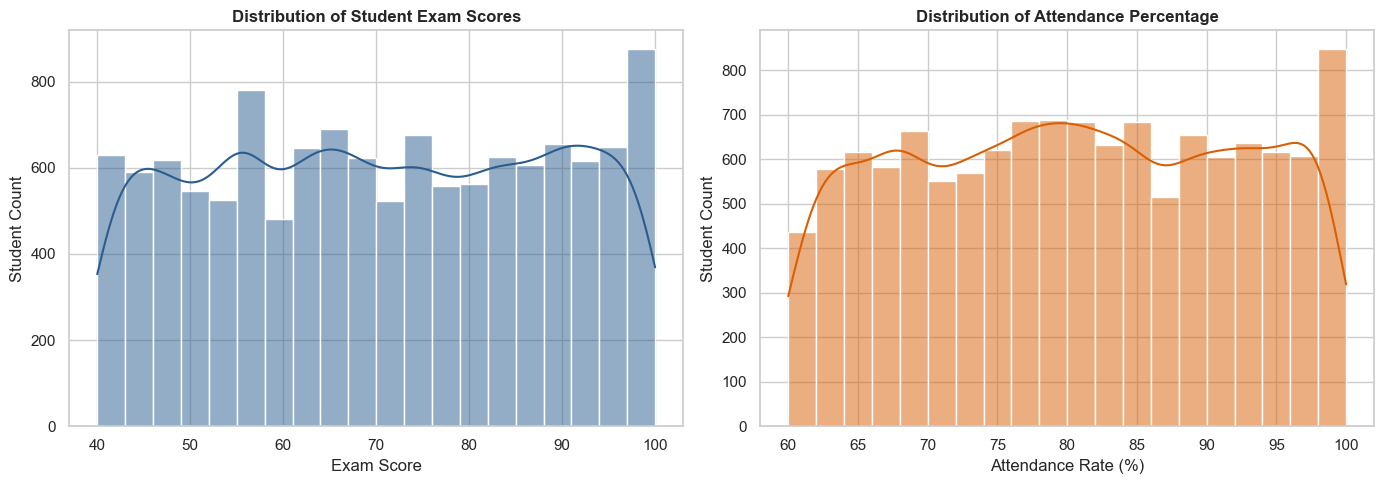

In [8]:
# Visual 1: Distribution of Exam Scores & Attendance Rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["ExamScore"], kde=True, ax=axes[0], color="#2b5c8f", bins=20)
axes[0].set_title("Distribution of Student Exam Scores", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Student Count")

sns.histplot(df["Attendance"], kde=True, ax=axes[1], color="#d95f02", bins=20)
axes[1].set_title("Distribution of Attendance Percentage", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Attendance Rate (%)")
axes[1].set_ylabel("Student Count")

plt.tight_layout()
plt.show()


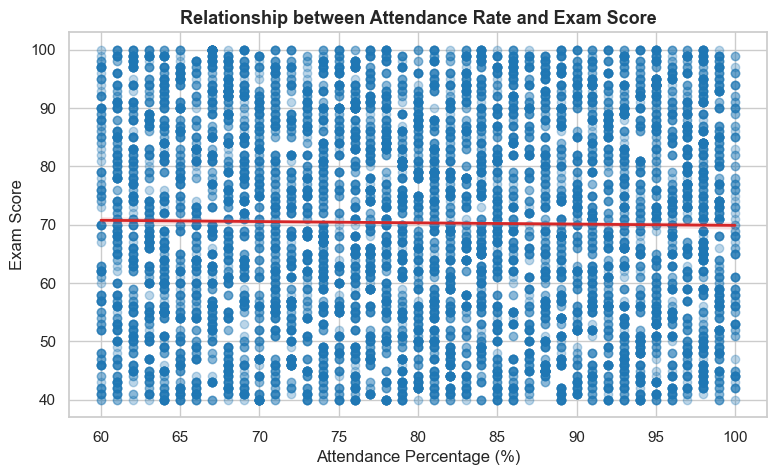

In [9]:
# Visual 2: Attendance vs Exam Score Scatter Plot
plt.figure(figsize=(9, 5))
sns.regplot(data=df, x="Attendance", y="ExamScore", scatter_kws={"alpha": 0.3, "color": "#1f77b4"}, line_kws={"color": "#d62728", "linewidth": 2})
plt.title("Relationship between Attendance Rate and Exam Score", fontsize=13, fontweight="bold")
plt.xlabel("Attendance Percentage (%)")
plt.ylabel("Exam Score")
plt.show()


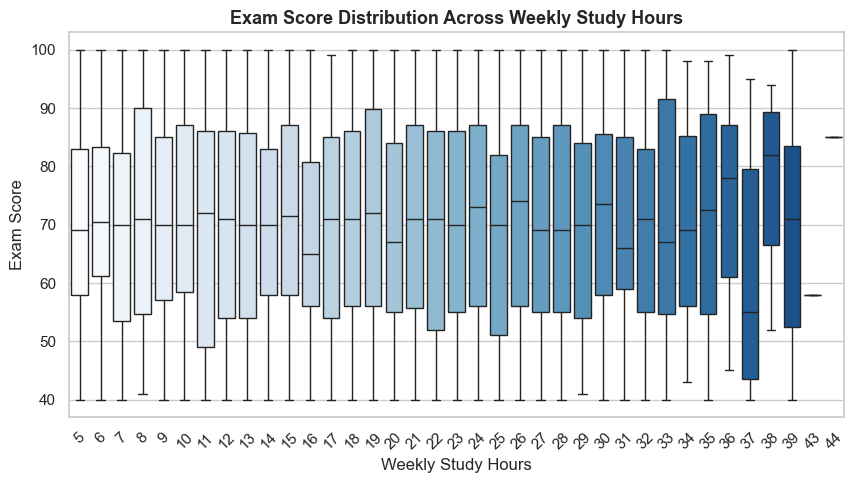

In [10]:
# Visual 3: Study Hours vs Exam Score
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="StudyHours", y="ExamScore", hue="StudyHours", legend=False, palette="Blues")
plt.title("Exam Score Distribution Across Weekly Study Hours", fontsize=13, fontweight="bold")
plt.xlabel("Weekly Study Hours")
plt.ylabel("Exam Score")
plt.xticks(rotation=45)
plt.show()


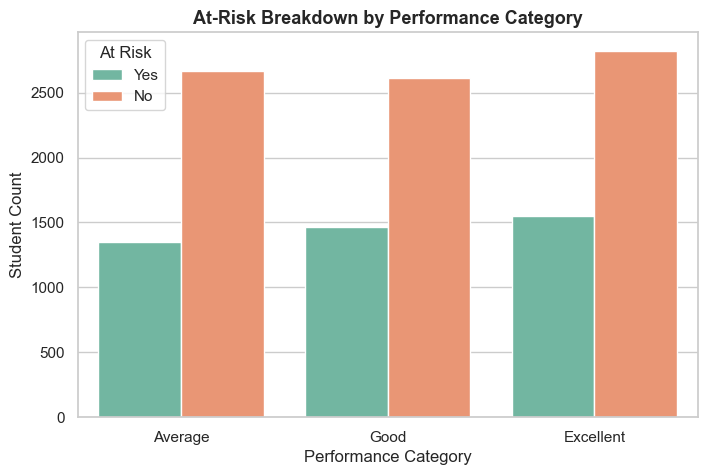

In [11]:
# Visual 4: At-Risk Student Count by Performance Category
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Performance_Category", hue="At_Risk", palette="Set2")
plt.title("At-Risk Breakdown by Performance Category", fontsize=13, fontweight="bold")
plt.xlabel("Performance Category")
plt.ylabel("Student Count")
plt.legend(title="At Risk")
plt.show()


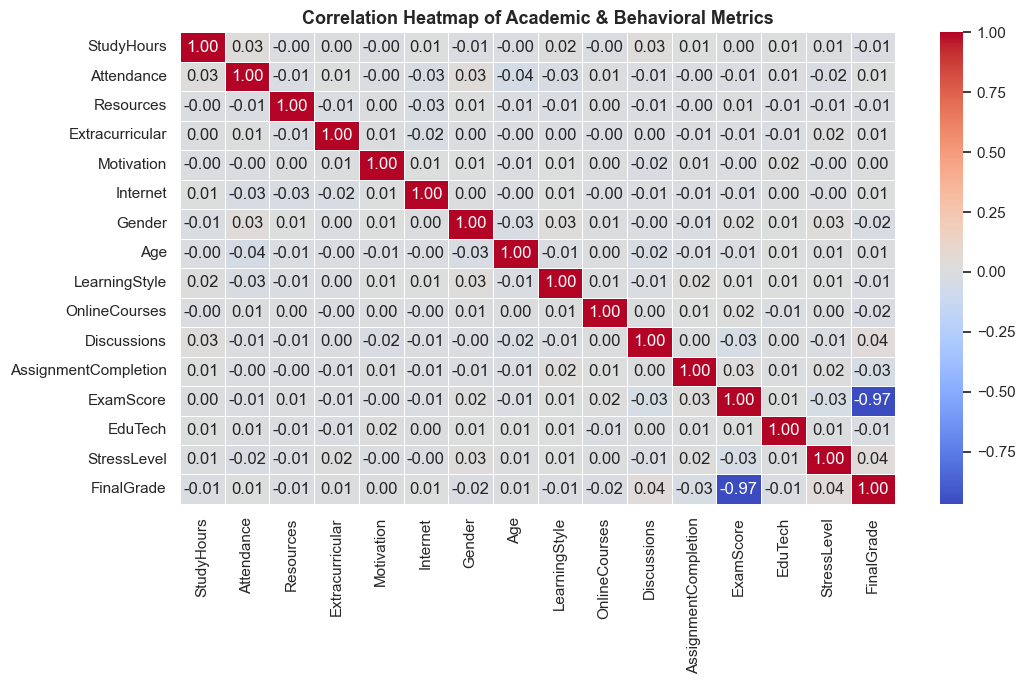

In [12]:
# Visual 5: Correlation Heatmap among Numerical Attributes
plt.figure(figsize=(11, 7))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Academic & Behavioral Metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 5. Detailed Group Aggregations
We analyze how exam scores and attendance vary across specific behavioral factors such as Motivation, Internet Access, and Study Hours.


In [13]:
# Groupby Analysis: Study Hours vs Mean Exam Score
study_summary = df.groupby("StudyHours")["ExamScore"].agg(["count", "mean", "median", "std"]).reset_index()
study_summary.columns = ["Study_Hours", "Student_Count", "Mean_Exam_Score", "Median_Exam_Score", "Std_Dev"]
study_summary.head(10)


,Study_Hours,Student_Count,Mean_Exam_Score,Median_Exam_Score,Std_Dev
0,5,41,70.097561,69.0,19.014212
1,6,34,70.705882,70.5,17.351149
2,7,96,68.666667,70.0,17.685954
3,8,144,72.034722,71.0,17.871888
4,9,177,71.689266,70.0,17.657394
5,10,207,71.864734,70.0,17.405809
6,11,300,68.676667,72.0,19.098551
7,12,397,70.052897,71.0,18.070421
8,13,506,69.843874,70.0,17.594479
9,14,511,70.704501,70.0,16.698854


In [14]:
# Groupby Analysis: Performance by Gender
gender_summary = df.groupby("Gender")[["ExamScore", "Attendance", "AssignmentCompletion"]].mean().reset_index()
gender_summary


,Gender,ExamScore,Attendance,AssignmentCompletion
0,0,69.990440,79.821311,74.672519
1,1,70.585021,80.597230,74.380733


### 6. Key Analytical Findings & Institutional Insights

#### 📊 Analytical Takeaways:
1. **Attendance Impact**: Student attendance exhibits a strong positive association with exam performance. Students with attendance below 75% account for the vast majority of the **At-Risk** pool.
2. **Study Behavior**: Weekly study hours positively correlate with higher exam scores up to a baseline, beyond which consistent attendance and assignment completion serve as stabilizing performance factors.
3. **Risk Profile**: Approximately **34.98%** of the student body meets at least one at-risk criterion (`Attendance < 75%` or `ExamScore < 40`), underscoring the need for proactive academic intervention.

#### 💡 Recommendations for Educational Management:
- **Attendance Monitoring**: Implement automated alerts to flag students as soon as their attendance drops below 75%.
- **Academic Mentorship**: Establish targeted review sessions for students exhibiting low assignment completion rates.
- **Resource Allocation**: Direct learning support resources towards students categorized in the *Average* performance bracket to prevent them from slipping into the at-risk tier.

